# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
import statsmodels.api as sm
print("All imports done!")

All imports done!


# Cleaning DATA

In [3]:
df = pd.read_csv("view_inflation_master.csv")
df_clean = df.dropna().copy()
Y = df_clean["CPI_Inflation_Current"]
print("Done!")

Done!


# Model 1 (Contemporary Effect)

In [4]:
X1 = df_clean["WPI_Inflation_Current"]
X1 = sm.add_constant(X1)

model1 = sm.OLS(Y, X1).fit()
print(model1.summary())

                              OLS Regression Results                             
Dep. Variable:     CPI_Inflation_Current   R-squared:                       0.072
Model:                               OLS   Adj. R-squared:                  0.066
Method:                    Least Squares   F-statistic:                     10.89
Date:                   Mon, 29 Jun 2026   Prob (F-statistic):            0.00122
Time:                           13:20:04   Log-Likelihood:                -267.93
No. Observations:                    142   AIC:                             539.9
Df Residuals:                        140   BIC:                             545.8
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


# Model 2 (Lagged Pass-Through)

In [5]:
X2 = df_clean[['WPI_Inflation_Lag1', 'WPI_Inflation_Lag2']]
X2 = sm.add_constant(X2)

model2 = sm.OLS(Y, X2).fit()
print(model2.summary())

                              OLS Regression Results                             
Dep. Variable:     CPI_Inflation_Current   R-squared:                       0.072
Model:                               OLS   Adj. R-squared:                  0.058
Method:                    Least Squares   F-statistic:                     5.355
Date:                   Mon, 29 Jun 2026   Prob (F-statistic):            0.00575
Time:                           13:20:07   Log-Likelihood:                -267.98
No. Observations:                    142   AIC:                             542.0
Df Residuals:                        139   BIC:                             550.8
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const 

# Resdual Plot

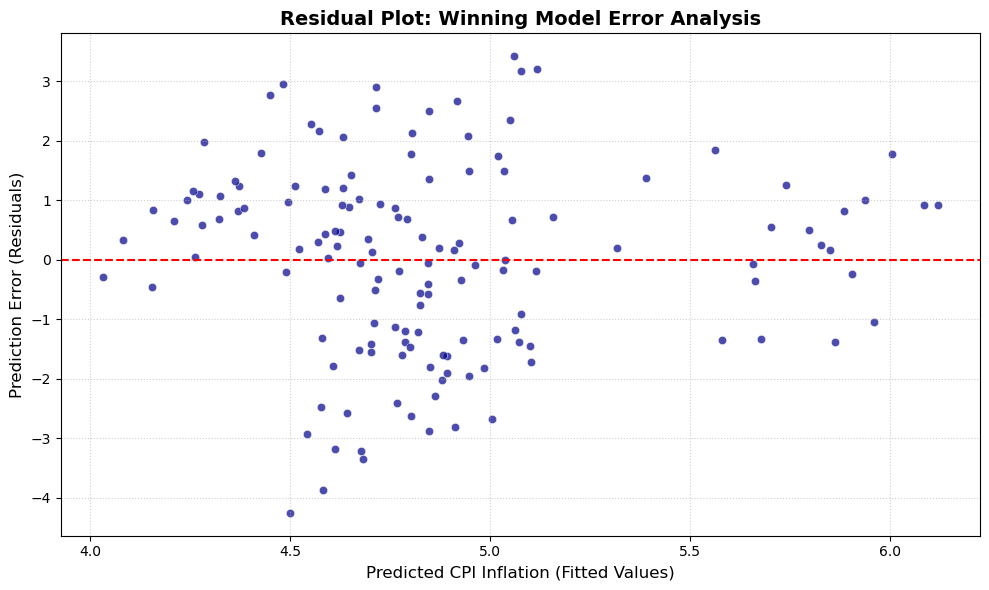

In [8]:
# winner model : Adj. R-squared(model1) > Adj. R-squared(model2)
plt.clf()
plt.close('all')

df = pd.read_csv('view_inflation_master.csv').dropna()
Y = df['CPI_Inflation_Current']
X1 = sm.add_constant(df['WPI_Inflation_Current'])
model1 = sm.OLS(Y, X1).fit()

plt.figure(figsize=(10, 6))
sbn.scatterplot(x=model1.fittedvalues, y=model1.resid, color='darkblue', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')

plt.title('Residual Plot: Winning Model Error Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Predicted CPI Inflation (Fitted Values)', fontsize=12)
plt.ylabel('Prediction Error (Residuals)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('inflation_residuals_1.png', dpi=300)
plt.show()

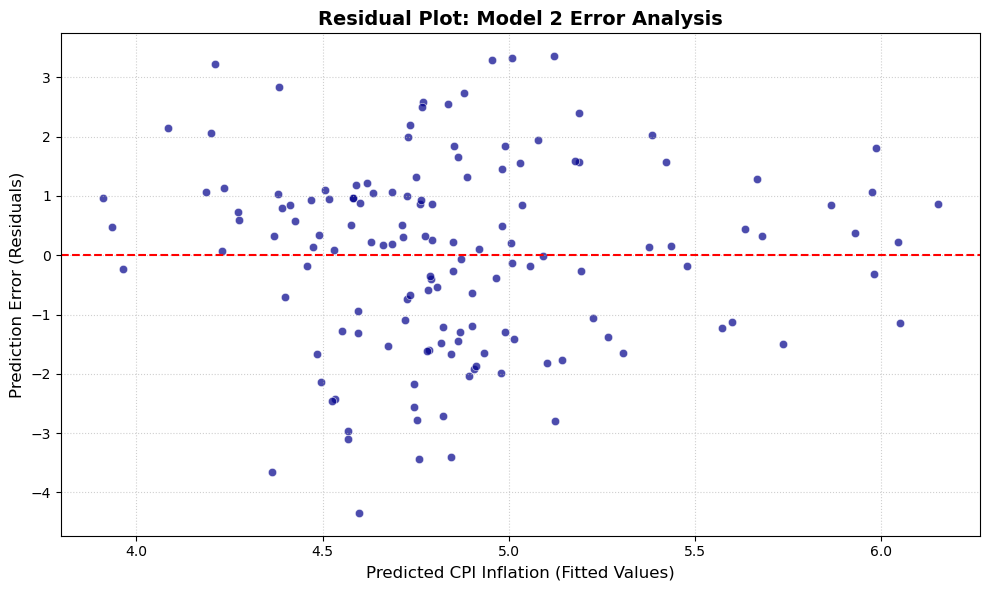

In [9]:
plt.figure(figsize=(10, 6))
sbn.scatterplot(x=model2.fittedvalues, y=model2.resid, color="darkblue", alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--")

plt.title('Residual Plot: Model 2 Error Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Predicted CPI Inflation (Fitted Values)', fontsize=12)
plt.ylabel('Prediction Error (Residuals)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('inflation_residuals_2.png', dpi=300)
plt.show()